# dNBR Fire Detection + Server-Side ML Classification (UDF)

Integrated pipeline: detect the burned area from Sentinel-2 imagery using the difference in
Normalized Burn Ratio (dNBR), then classify the vegetation composition of that burned area with
a Random Forest trained on national forest inventory (NFI) labels. Classification runs
**server-side** via `apply_dimension` with a UDF, so only the small training-feature download and
the final classification GeoTIFF cross the wire — the full-resolution prediction raster never has
to be downloaded and predicted on locally.

```
Sync download:    load_collection → aggregate_spatial(label points) → download JSON
                                            ↓
                              features passed into UDF context
                                            ↓
Large batch job:  load_collection → apply_dimension(bands, UDF) → GeoTIFF
```

This notebook merges `dNBR_Portugal.ipynb` (fire detection) and `ML_UDF.ipynb` (server-side ML)
into one self-contained run — no intermediate `clean_mask_*.tif` handoff between notebooks
required.

## Overview

1. Import Required Libraries
2. Connect to OpenEO Backend
3. dNBR Fire Area Detection
   - 3.1 Load Pre and Post Fire Satellite Images
   - 3.2 Calculate dNBR and Fire Mask
   - 3.3 Visualize dNBR
4. ML Vegetation Classification via Server-Side UDF
   - 4.1 Load NFI Labels
   - 4.2 Download Spectral Features at Label Locations (small batch job)
   - 4.3 Validate Classifier on a Held-Out Split
   - 4.4 Define ML UDF
   - 4.5 Submit Prediction Batch Job
5. Visualize Results

## 1. Import Required Libraries

In [1]:
import glob
import json
import textwrap

import geopandas
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import ndimage
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import openeo
from openeo import UDF
from openeo_udp import ParameterManager

## 2. Connect to OpenEO Backend

In [2]:
param_manager = ParameterManager('dNBR_Portugal.params.py')

connection, current_params = param_manager.quick_connect(
    param_set="reriz_gafanhao_north_portugal_2024",
    endpoint="copernicus_dataspace",
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: reriz_gafanhao_north_portugal_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Reriz e Gafanhao, North Portugal
🔄 Parameters mapped for endpoint copernicus_dataspace:


In [3]:
def load_and_sample(params, time, bands, res=100):
    """Load a Sentinel-2 collection reduced to the last image and resampled."""
    s2cube = connection.load_collection(
        params["collection"].default,
        temporal_extent=time,
        spatial_extent=params["bounding_box"].default,
        bands=bands,
        properties={"eo:cloud_cover": lambda x: x <= params["cloud_cover"].default},
    )
    s2cube = s2cube.reduce_dimension(dimension="t", reducer="last")
    s2cube = s2cube.resample_spatial(resolution=[res, res], method="near")
    return s2cube


def download_cube(cube, out_folder, out_format, batch=True):
    """
    Input: Cube to download, output folder, output format (e.g. "JSON", "GTiff"),
           batch (False skips the batch-job queue for small/fast results —
           out_folder is then used directly as the output file path)
    Output: None, downloads the cube's results into out_folder
    """
    if batch:
        job = cube.create_job(out_format=out_format)
        job.start_and_wait()
        job.get_results().download_files(out_folder)
    else:
        cube.download(out_folder, format=out_format)

## 3. dNBR Fire Area Detection

Detect the fire area's main body and create a mask of it, using the difference in Normalized Burn
Ratio between a pre-fire and a post-fire Sentinel-2 image.

### 3.1 Load Pre and Post Fire Satellite Images

In [4]:
res_dnbr = 20

s2cube_pre = load_and_sample(
    current_params, current_params["time_pre"].default, current_params["bands_fire"].default, res_dnbr
)
s2cube_post = load_and_sample(
    current_params, current_params["time_post"].default, current_params["bands_fire"].default, res_dnbr
)

### 3.2 Calculate dNBR and Fire Mask

In [5]:
def calculate_nbr(data):
    """Input: Cube with bands 8A and 12. Output: NBR"""
    B8A, B12 = data[0], data[1]
    nbr = (B8A - B12) / (B8A + B12)
    return nbr


def calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold):
    """Input: Pre and post fire NBR as cube, burn threshold. Output: dNBR and dNBR mask"""
    dnbr = nbr_pre - nbr_post
    dnbr_mask = dnbr > burn_threshold
    return dnbr, dnbr_mask

In [6]:
nbr_post = s2cube_post.reduce_dimension(dimension="bands", reducer=calculate_nbr)
nbr_pre = s2cube_pre.reduce_dimension(dimension="bands", reducer=calculate_nbr)

burn_threshold_default = 0.3
dnbr, dnbr_mask = calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold_default)

In [7]:
location_slug = current_params["location_name"].replace(" ", "_").replace(",", "").lower()

dnbr_tiff = dnbr.save_result("GTiff")
dnbr_file = f"dNBR_{location_slug}.tif"
connection.download({"process_graph": dnbr_tiff.flat_graph()}, dnbr_file)

mask_result = dnbr_mask.save_result("GTiff")
mask_file = f"firemask_{location_slug}.tif"
connection.download({"process_graph": mask_result.flat_graph()}, mask_file)

In [8]:
with rasterio.open(dnbr_file) as src:
    dnbr_gtiff = src.read(1)

with rasterio.open(mask_file) as src:
    mask_gtif = src.read(1)
    trans = src.transform
    crs = src.crs
    mask_profile = src.profile

# Keep only the largest connected component -> main body of the fire
mask_gtif = ndimage.binary_dilation(mask_gtif, structure=np.ones((3, 3)), iterations=1)
labeled, n = ndimage.label(mask_gtif, structure=np.ones((3, 3)))
sizes = ndimage.sum(mask_gtif, labeled, range(1, n + 1))
clean_mask = (labeled == sizes.argmax() + 1).astype("uint8")

/var/folders/6n/l9czk0nj5hd1pnryp2mg3dr00000gn/T/ipykernel_55768/2565016531.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dnbr_gtiff = src.read(1)
/var/folders/6n/l9czk0nj5hd1pnryp2mg3dr00000gn/T/ipykernel_55768/2565016531.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  mask_gtif = src.read(1)


### 3.3 Visualize dNBR

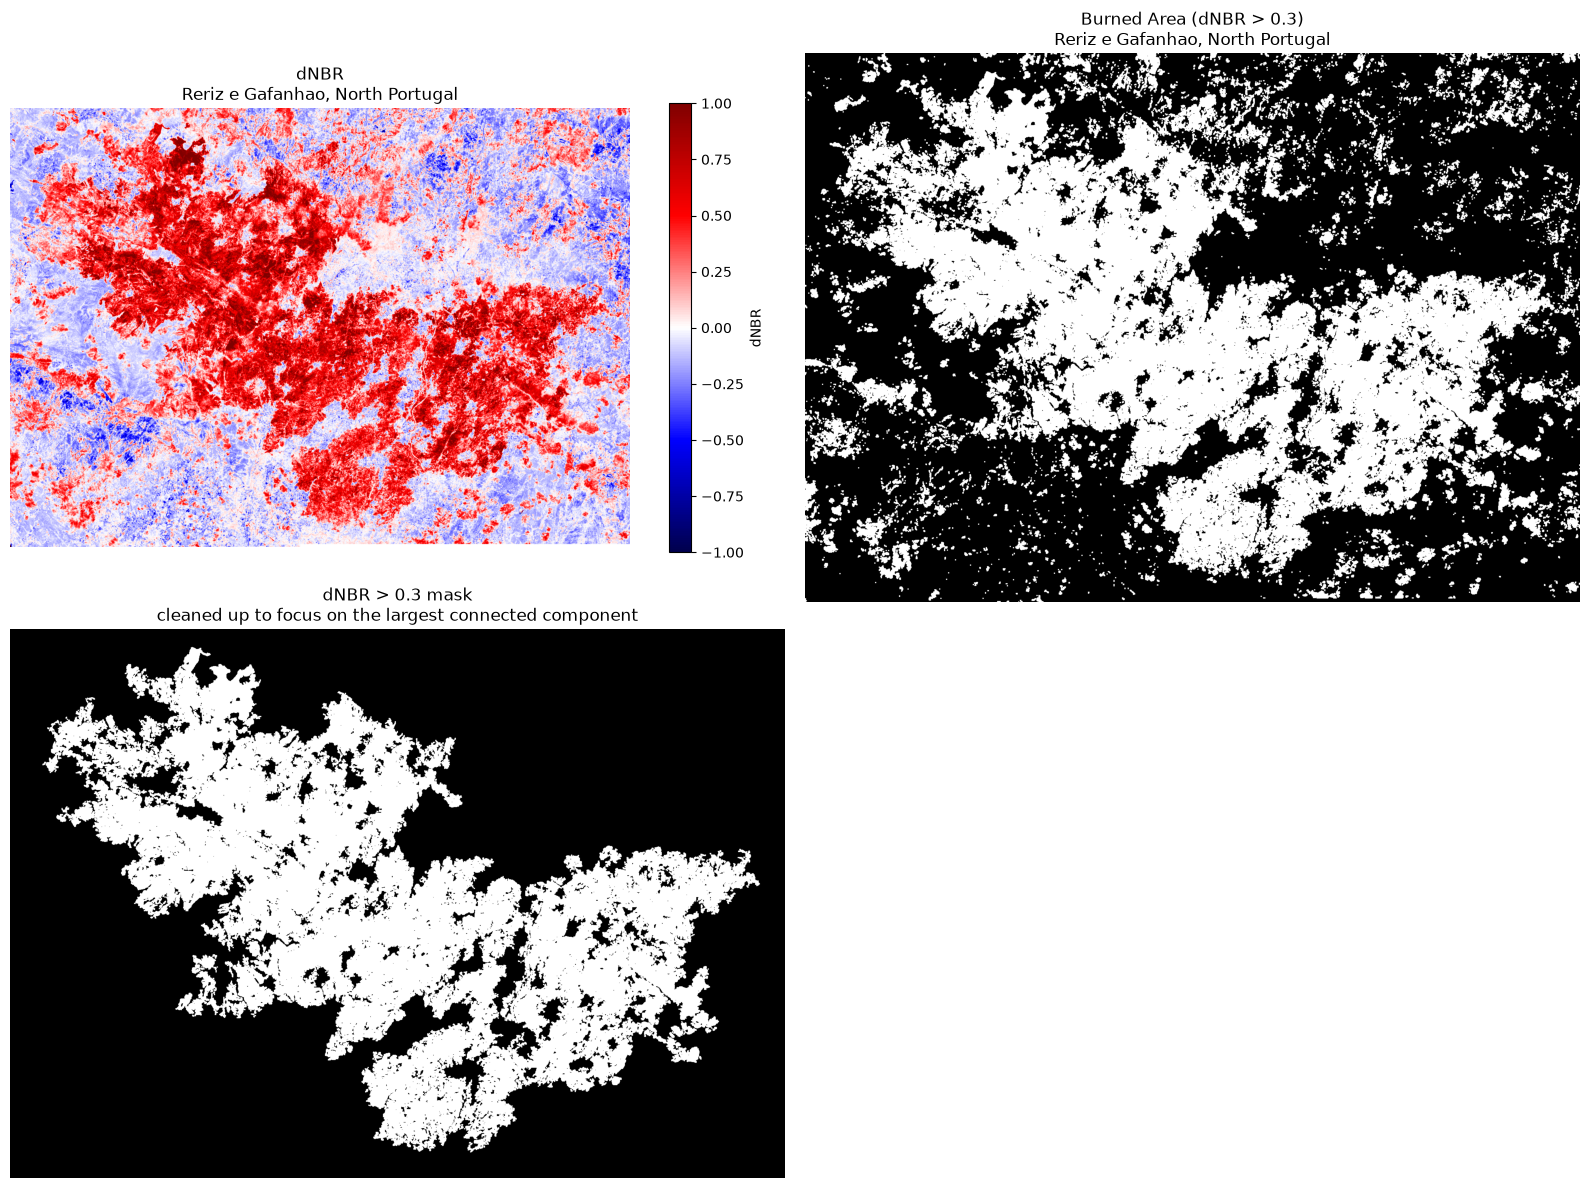

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes.flat
fig.delaxes(ax4)

im1 = ax1.imshow(dnbr_gtiff, cmap="seismic", vmin=-1, vmax=1)
fig.colorbar(im1, ax=ax1, label="dNBR", shrink=0.8)
ax1.set_title(f"dNBR\n{current_params['location_name']}")
ax1.axis("off")

ax2.imshow(mask_gtif, cmap="gray")
ax2.set_title(f"Burned Area (dNBR > {burn_threshold_default})\n{current_params['location_name']}")
ax2.axis("off")

ax3.imshow(clean_mask, cmap="gray")
ax3.set_title(f"dNBR > {burn_threshold_default} mask\ncleaned up to focus on the largest connected component")
ax3.axis("off")

plt.tight_layout()
plt.show()

In [10]:
clean_mask_file = f"clean_mask_{location_slug}.tif"
profile = mask_profile.copy()
profile.update(dtype=clean_mask.dtype, count=1)

with rasterio.open(clean_mask_file, "w", **profile) as dst:
    dst.write(clean_mask, 1)

## 4. ML Vegetation Classification via Server-Side UDF

Random Forest training features are downloaded for the small set of NFI label points, then the
trained-model logic is shipped to the backend as a UDF and applied to the full raster with
`apply_dimension` — classification of every pixel happens server-side, and only the resulting
single-band GeoTIFF is downloaded.

### 4.1 Load NFI Labels

In [11]:
nfi_labels = geopandas.read_file("nfi_labels.geojson")
geojson_labels = json.loads(nfi_labels[["label", "geometry"]].to_json())

y_train_str = nfi_labels["label"].values.tolist()
label_names = sorted(set(y_train_str))  # sorted list — index = integer class ID

### 4.2 Download Spectral Features at Label Locations

In [12]:
res = 20
s2_train = load_and_sample(
    current_params,
    current_params["time_post"].default,
    current_params["bands_ml"].default,
    res,
)

features_cube = s2_train.aggregate_spatial(geojson_labels, reducer="mean")

features_out_file = "training_features.json"
download_cube(features_cube, features_out_file, "JSON", batch=False)

with open(features_out_file) as f:
    raw_train = json.load(f)

X_train_raw = np.array(raw_train, dtype=float)
y_train_raw = np.array(y_train_str)

# Drop label points that landed on a nodata/cloud-masked pixel (aggregate_spatial returns
# null -> NaN for those) — RandomForestClassifier can't fit on NaN features.
valid_train = ~np.isnan(X_train_raw).any(axis=1)
n_dropped = (~valid_train).sum()
if n_dropped:
    print(f"Dropping {n_dropped} of {len(valid_train)} label points with missing feature values")

X_train = X_train_raw[valid_train]
y_train_str = y_train_raw[valid_train].tolist()

### 4.3 Validate Classifier on a Held-Out Split

Before shipping the classifier off to run server-side on the full raster, fit it on a train/test
split locally and check accuracy — the UDF in 4.4 will retrain on the *full* label set for
deployment, but this gives a sense of expected performance first.

In [13]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train_str, test_size=0.2, random_state=42, stratify=y_train_str
)
validation_clf = RandomForestClassifier(n_estimators=100, random_state=42)
validation_clf.fit(X_tr, y_tr)

print(classification_report(y_te, validation_clf.predict(X_te)))

                precision    recall  f1-score   support

    Eucalyptus       0.21      0.19      0.20        16
Maritime Pines       0.63      0.38      0.47        32
     Shrubland       0.63      0.80      0.70        55

      accuracy                           0.57       103
     macro avg       0.49      0.45      0.46       103
  weighted avg       0.57      0.57      0.55       103



### 4.4 Define ML UDF

The UDF uses the `apply_datacube` signature and is submitted to the backend as a code string. The
backend calls it once per spatial chunk of the S2 raster.

Inside the UDF:
1. Reconstruct `X_train`/`y_train` from `context`
2. Train a `RandomForestClassifier` on the training set
3. Reshape the chunk and predict a class ID per pixel
4. Return predicted class labels

Training data is small (~500 pts × n bands) and the model is deterministic, so re-training per
chunk is fast and always yields the same result.

In [14]:
udf_code = textwrap.dedent("""
    import numpy as np
    import xarray as xr
    from sklearn.ensemble import RandomForestClassifier

    def apply_datacube(cube: xr.DataArray, context: dict) -> xr.DataArray:
        X_train   = np.array(context["X_train"])
        y_train   = np.array(context["y_train"])
        label_names = context["label_names"]         # sorted list; index == class ID
        class_to_int = {cls: float(i) for i, cls in enumerate(label_names)}

        # Train on the full training set (fast: ~500 pts, 2 bands)
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train)

        # Predict on the raster chunk: (n_bands, height, width)
        arr = cube.values
        n_bands, height, width = arr.shape
        X_pred = arr.reshape(n_bands, -1).T          # (pixels, n_bands)
        valid  = ~np.isnan(X_pred).any(axis=1)

        preds_str  = np.full(height * width, "NoData", dtype=object)
        preds_str[valid] = clf.predict(X_pred[valid])
        preds_float = np.array([class_to_int.get(p, -1.0) for p in preds_str])

        return xr.DataArray(
            preds_float.reshape(1, height, width),
            dims=cube.dims,
        )
""")

### 4.5 Submit Prediction Batch Job

`context` carries the training features + labels (the full cleaned set, not just the validation
split). The prediction raster is processed entirely server-side — only the single-band
classification GeoTIFF is downloaded.

In [15]:
context = {
    "X_train": X_train.tolist(),   # (n_points, n_bands) as plain Python lists
    "y_train": y_train_str,
    "label_names": label_names,
}

udf = UDF(code=udf_code, runtime="Python", context=context)

# Prediction cube stays server-side — UDF is applied along the bands dimension
s2_pred = load_and_sample(
    current_params,
    current_params["time_post"].default,
    current_params["bands_ml"].default,
    res,
)
result = s2_pred.apply_dimension(process=udf, dimension="bands")

pred_out_folder = "udf_prediction"
download_cube(result, pred_out_folder, "GTiff")

0:00:00 Job 'j-260707151558444aaf6bbde73c914287': send 'start'
0:00:04 Job 'j-260707151558444aaf6bbde73c914287': created (progress 0%)
0:00:09 Job 'j-260707151558444aaf6bbde73c914287': queued (progress 0%)
0:00:16 Job 'j-260707151558444aaf6bbde73c914287': queued (progress 0%)
0:00:24 Job 'j-260707151558444aaf6bbde73c914287': queued (progress 0%)
0:00:34 Job 'j-260707151558444aaf6bbde73c914287': queued (progress 0%)
0:00:46 Job 'j-260707151558444aaf6bbde73c914287': queued (progress 0%)
0:01:02 Job 'j-260707151558444aaf6bbde73c914287': queued (progress 0%)
0:01:21 Job 'j-260707151558444aaf6bbde73c914287': running (progress N/A)
0:01:45 Job 'j-260707151558444aaf6bbde73c914287': running (progress N/A)
0:02:15 Job 'j-260707151558444aaf6bbde73c914287': running (progress N/A)
0:02:52 Job 'j-260707151558444aaf6bbde73c914287': running (progress N/A)
0:03:39 Job 'j-260707151558444aaf6bbde73c914287': finished (progress 100%)


## 5. Visualize Results

/var/folders/6n/l9czk0nj5hd1pnryp2mg3dr00000gn/T/ipykernel_55768/3404849308.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pred_raster = src.read(1).astype(float)


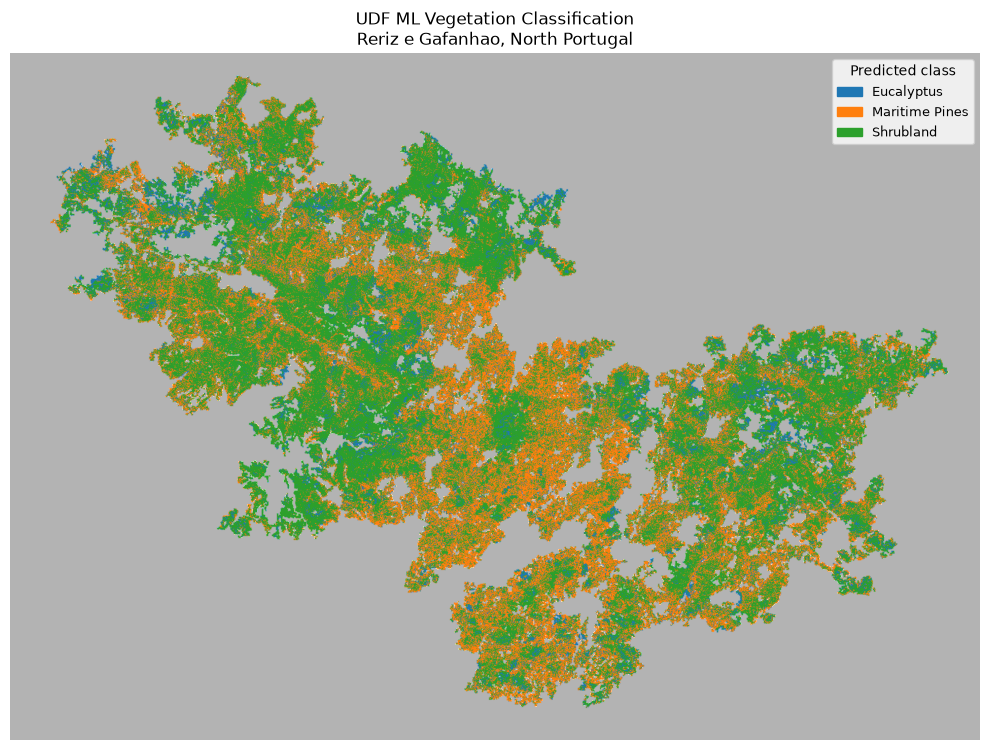

In [16]:
pred_tiff = glob.glob("udf_prediction/*.tif")[0]
with rasterio.open(pred_tiff) as src:
    pred_raster = src.read(1).astype(float)

pred_raster[pred_raster < 0] = np.nan  # -1 -> NoData
pred_fire = np.where(clean_mask == 1, pred_raster, np.nan)

n_classes = len(label_names)
colors = [plt.get_cmap("tab10")(i) for i in range(n_classes)]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_classes, 1), ncolors=n_classes)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clean_mask, cmap="gray", interpolation="none", alpha=0.3)
ax.imshow(pred_fire, cmap=cmap, norm=norm)
legend_patches = [mpatches.Patch(color=colors[i], label=name) for i, name in enumerate(label_names)]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Predicted class")
ax.set_title(f"UDF ML Vegetation Classification\n{current_params['location_name']}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [17]:
fire_preds = pred_raster[clean_mask == 1]
fire_preds = fire_preds[~np.isnan(fire_preds)].astype(int)

print("Prediction counts in fire area:")
for i, name in enumerate(label_names):
    count = (fire_preds == i).sum()
    pct = 100 * count / len(fire_preds)
    print(f"  {name:<18} {count:>7,}  ({pct:.1f}%)")
print(f"  {'Total':<18} {len(fire_preds):>7,}")

Prediction counts in fire area:
  Eucalyptus          94,047  (11.7%)
  Maritime Pines     271,960  (33.8%)
  Shrubland          437,702  (54.5%)
  Total              803,709
